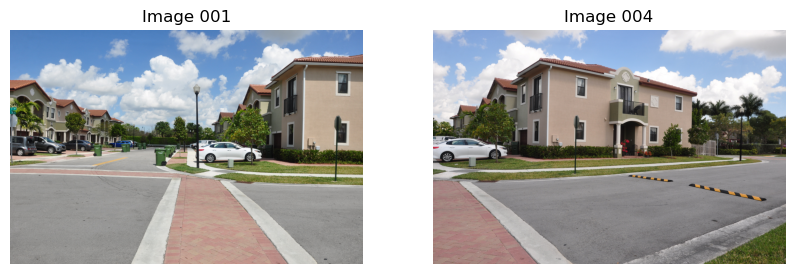

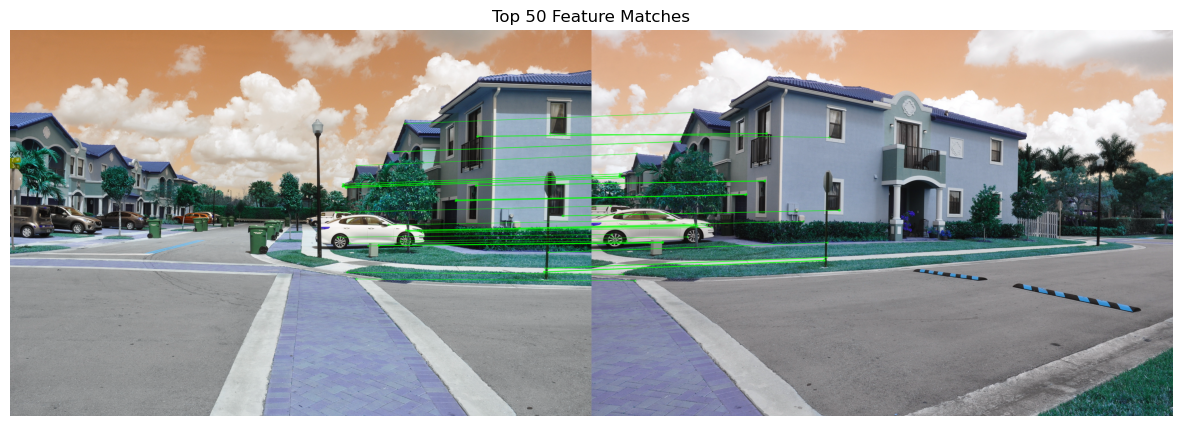

Homography Matrix:
 [[ 2.35201920e+00 -2.53949335e-02 -2.56973157e+03]
 [ 4.27330316e-01  2.00841900e+00 -6.93607394e+02]
 [ 6.69507736e-04 -2.06926188e-05  1.00000000e+00]]


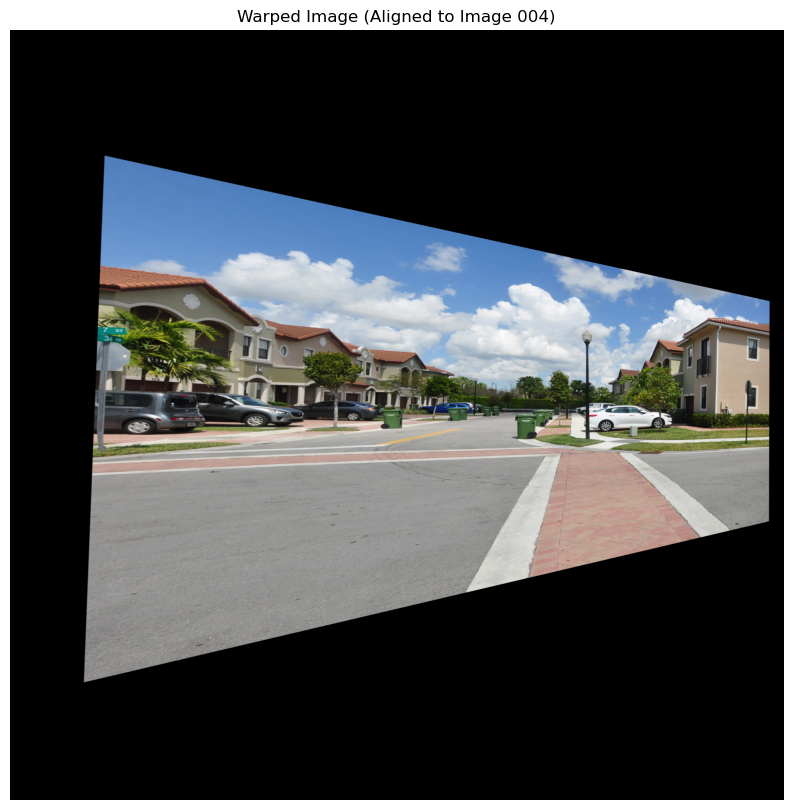

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Paths
img1_path = 'Assignment5_Files/Panorama/001.jpg'
img2_path = 'Assignment5_Files/Panorama/004.jpg'

# 1. Load images
img1 = cv.imread(img1_path)
img2 = cv.imread(img2_path)

if img1 is None or img2 is None:
    raise FileNotFoundError("One or both images not found.")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
plt.title("Image 001")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
plt.title("Image 004")
plt.axis('off')
plt.show()

# 2. Detect and describe features using ORB
orb = cv.ORB_create(5000)
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# Match features using BFMatcher
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# Draw top matches
top_matches = matches[:50]
match_img = cv.drawMatches(img1, kp1, img2, kp2, top_matches, None, matchColor=(0, 255, 0), singlePointColor=(255, 0, 0),
 flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15,10))
plt.imshow(match_img)
plt.title("Top 50 Feature Matches")
plt.axis('off')
plt.show()

# 3. Compute homography matrix
src_pts = np.float32([kp1[m.queryIdx].pt for m in top_matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in top_matches]).reshape(-1,1,2)

H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
print("Homography Matrix:\n", H)

# Shift right down
tx = img2.shape[1]*1.5  # horizontal shift
ty = img2.shape[0]  # vertical shift

translation = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
], dtype=np.float32)

# Combine translation with homography
H_shifted = translation @ H

# 4. Warp img1 to align with img2
h2, w2 = img2.shape[:2]
# Use a larger canvas to accommodate the shift
canvas_width = img2.shape[1] * 2
canvas_height = img2.shape[0] * 3

aligned_img = cv.warpPerspective(img1, H_shifted, (canvas_width, canvas_height))


plt.figure(figsize=(15,10))
plt.imshow(cv.cvtColor(aligned_img, cv.COLOR_BGR2RGB))
plt.title("Warped Image (Aligned to Image 004)")
plt.axis('off')
plt.show()